In [2]:
%load_ext autoreload
%autoreload 2

import collections
import math
import numpy as np
import re
import scipy.stats
import tqdm
import torch
from torch import tensor, Tensor
from typing import Iterable, Any

import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker
import pandas as pd
import seaborn as sns

import block_formats.analysis as A
import block_formats.experiments as E
import block_formats.quantisation as Q
import plot_utils

plot_utils.configure()
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Recommend (Ubuntu):
  sudo apt-get install cm-super dvipng fonts-cmu texlive-latex-extra


### `kl_fisher_prediction_noise`

In [2]:
fisher_sum = {run.config.model: run.summary.fisher for run in E.runs("20250423-fisher")}
weight_stats = {run.config.model: run.summary.weight_stats for run in E.runs("20250423-weight-stats")}

In [3]:
runs = E.runs("20250502-noise-sensitivity")
# note: 'google/gemma-3-4b-pt' was incomplete
display(dict(collections.Counter(run.config.model for run in runs)))

{'meta-llama/Llama-3.2-1B': 339,
 'meta-llama/Llama-3.2-3B': 591,
 'meta-llama/Llama-3.1-8B': 678,
 'google/gemma-3-1b-pt': 549,
 'google/gemma-3-4b-pt': 1209,
 'Qwen/Qwen2.5-0.5B': 507,
 'Qwen/Qwen2.5-1.5B': 591,
 'Qwen/Qwen2.5-3B': 759,
 'Qwen/Qwen2.5-7B': 594,
 'microsoft/phi-4': 486}

In [8]:
def get_row(run: E.AttrDict) -> dict[str, Any]:
    if run.meta.status == "finished" and "vision_model" not in run.config.test.parameter and "multi_modal_projector" not in run.config.test.parameter:
        return dict(
            model=run.config.model.split("/")[1],
            scale=run.config.test.scale,
            parameter=run.config.test.parameter,
            fisher_sum=fisher_sum[run.config.model][run.config.test.parameter],
            rm2=weight_stats[run.config.model][run.config.test.parameter].rm2,
            kl_div=tensor(run.summary.kl_div).mean().item(),
        )

df = pd.DataFrame.from_records(filter(None, map(get_row, runs)))
df["kl_div_prediction"] = 0.5 * (df.scale * df.rm2) ** 2 * df.fisher_sum
df["magnitude_prediction"] = 0.5 * (df.scale * df.rm2) ** 2
df.head()

,model,scale,parameter,fisher_sum,rm2,kl_div,kl_div_prediction,magnitude_prediction
0,Llama-3.2-1B,0.25,model.embed_tokens.weight,7028.244600,0.021907,0.100927,0.105403,0.000015
1,Llama-3.2-1B,0.25,model.layers.0.self_attn.q_proj.weight,7.463257,0.036875,0.001434,0.000317,0.000042
2,Llama-3.2-1B,0.25,model.layers.0.self_attn.k_proj.weight,12.020443,0.047735,0.002423,0.000856,0.000071
3,Llama-3.2-1B,0.25,model.layers.0.self_attn.v_proj.weight,1267.261500,0.009144,0.006154,0.003311,0.000003
4,Llama-3.2-1B,0.25,model.layers.0.self_attn.o_proj.weight,736.610960,0.011592,0.005260,0.003093,0.000004


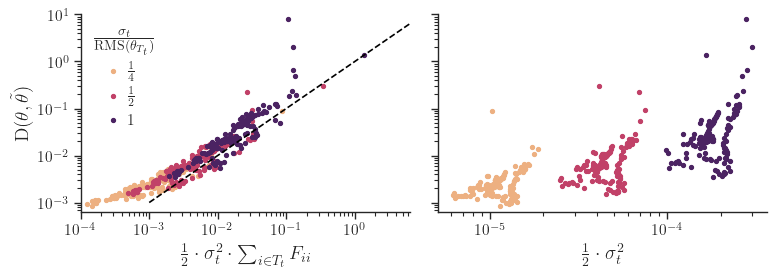

In [13]:
model = "Llama-3.1-8B"
model = 'phi-4'
fig, axs = plt.subplots(ncols=2, sharey=True)
for ax, predictor in zip(axs, ["kl_div_prediction", "magnitude_prediction"]):
    scales = sorted(df.scale.unique())
    for scale, color in zip(scales, plot_utils.SEQ_PALETTE(matplotlib.colors.LogNorm()(scales))):
        d = df[(df.model == model) & (df.scale == scale)]
        ax.scatter(d[predictor], d.kl_div, color=color, label=plot_utils.format_fraction()(scale, None))
    if predictor == "kl_div_prediction":
        ax.plot([10**-3, 10], [10**-3, 10], "k--")
    ax.set_xscale("log")
    ax.set_yscale("log")
    if predictor == "kl_div_prediction":
        ax.set_xlabel(r"$\frac{1}{2} \cdot \sigma_t^2 \cdot \sum_{i \in T_t} F_{ii}$")
        ax.set_xlim((10**-4, 10**0.8))
    if predictor == "magnitude_prediction":
        ax.set_xlabel(r"$\frac{1}{2} \cdot \sigma_t^2$")
axs[0].set_ylim((10**-3.2, 10**1))
axs[0].legend(title=r"$\frac{\sigma_t}{\text{RMS}(\theta_{T_t})}$", handletextpad=1., handlelength=0)
axs[0].set_ylabel(r"$\mathrm{D}(\theta, \tilde{\theta})$")
plot_utils.tidy(fig)
# plot_utils.save("kl_fisher_prediction_noise")

### `fisher_structure`

Analysis of structure in the diagonal Fisher, to justify the constant-per-tensor approximation

In [ ]:
# Warning: this can take ~2m
fisher = E.fisher.fetch_fisher("meta-llama/Llama-3.1-8B", device=DEVICE)

remote: Updating references: 100% (1/1)           


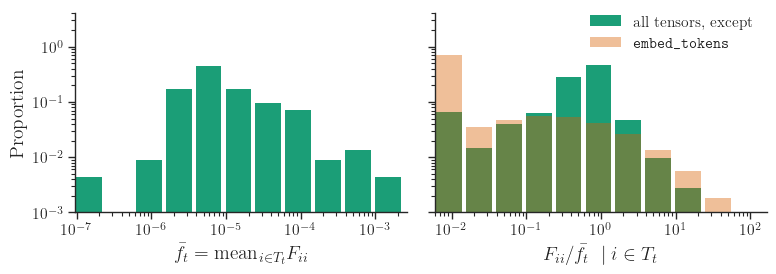

In [233]:
def count_histogram(tensors: Iterable[Tensor], bins: Tensor) -> Tensor:
    boundaries = (bins[1:] + bins[:-1]) / 2
    counts = torch.zeros(len(bins), dtype=torch.int64, device=DEVICE)
    for t in tensors:
        counts += torch.bincount(torch.bucketize(t, boundaries), minlength=len(bins))
    return counts

fig, (ax0, ax1) = plt.subplots(ncols=2, sharey=True)
last_bin_ratio = 0.6  # make sure we clip the last bin, since the bin edges are open
width_ratio = 0.5  # hack
xrange = 4
xstep = 0.4

x0 = -6.8
bins = 10 ** torch.arange(x0, x0 + xrange + 1e-3, xstep, device=DEVICE)
binw = torch.diff(torch.cat([bins, bins[-1:] ** 2 / bins[-2]])).cpu() * width_ratio
counts = count_histogram([torch.stack([t.mean(dtype=torch.float32) for t in fisher.values()])], bins)
counts = counts / counts.sum()
ax0.bar(bins.cpu(), counts.cpu(), width=binw, lw=0)

ax0.set_xscale("log")
ax0.set_xlabel(r"$\bar{f}_t = \mathrm{mean}_{i \in T_t} F_{ii}$")
ax0.set_xlim((bins[0].item() * last_bin_ratio, bins[-1].item() / last_bin_ratio))

bins = 10 ** torch.arange(-xrange/2, xrange/2 + 1e-3, xstep, device=DEVICE)
binw = torch.diff(torch.cat([bins, bins[-1:] ** 2 / bins[-2]])).cpu() * width_ratio
counts = count_histogram((fisher[k].flatten().float() / fisher[k].mean(dtype=torch.float32) for k in fisher if k != "model.embed_tokens.weight"), bins)
counts = counts / counts.sum()
ax1.bar(bins.cpu(), counts.cpu(), width=binw, label="all tensors, except", lw=0)
counts = count_histogram((fisher[k].flatten().float() / fisher[k].mean(dtype=torch.float32) for k in ["model.embed_tokens.weight"]), bins)
counts = counts / counts.sum()
ax1.bar(bins.cpu(), counts.cpu(), width=binw, lw=0, alpha=.4, label=r"\texttt{embed_tokens}")

ax1.set_xscale("log")
ax1.set_yscale("log")
ax1.set_xlim((bins[0].item() * last_bin_ratio, bins[-1].item() / last_bin_ratio))
ax1.set_xlabel(r"$F_{ii} / \bar{f}_t \;\mid i \in T_t$")
ax1.legend(loc="upper right", bbox_to_anchor=(1, 1.06))

ax0.set_ylim((10**-3, 4))
ax0.set_ylabel("Proportion")

plot_utils.tidy(fig)
plot_utils.save("fisher_structure")

In [224]:
display(pd.DataFrame.from_dict([dict(tensor=k, fisher_mean=v.mean(dtype=torch.float32).item()) for k, v in fisher.items()]).sort_values("fisher_mean"))

,tensor,fisher_mean
7,model.layers.0.self_attn.q_proj.weight,2.031723e-07
5,model.layers.0.self_attn.k_proj.weight,1.590264e-06
119,model.layers.23.self_attn.q_proj.weight,1.719210e-06
126,model.layers.24.self_attn.q_proj.weight,1.944991e-06
175,model.layers.30.self_attn.q_proj.weight,2.101389e-06
...,...,...
169,model.layers.3.self_attn.v_proj.weight,4.142772e-04
92,model.layers.2.self_attn.v_proj.weight,5.397277e-04
15,model.layers.1.self_attn.v_proj.weight,9.105785e-04
9,model.layers.1.mlp.down_proj.weight,1.001650e-03


In [ ]:
del fisher  # memory!

### `tab:bit_count_contributors`

In [252]:
model = "meta-llama/Llama-3.1-8B"
fisher_sum = E.fisher.fetch_fisher_sum(model, experiment_name="20250423-fisher")
weight_stats = E.weight_stats.fetch_weight_stats(model, experiment_name="20250423-weight-stats")
nelement = {k: math.prod(v.shape) for k, v in weight_stats.items()}
run = E.run("20250503-llama8b-refresh/rtaLm8kbgd")
assert run.config.model == model
print(run.config.test.fmt_str, f"KL: {tensor(run.summary.kl_div).mean():.3f}")

def dist_stats(t: Tensor) -> Tensor:
    a, b = t.quantile(tensor([0.1, 0.9]))
    return dict(std=t.std().item(), range9010=(b - a).item())

fisher = tensor([fisher_sum[k] / nelement[k] for k in weight_stats])
rms = tensor([weight_stats[k].rm2 for k in weight_stats])
epsilon = tensor([run.summary.params[k].rmse / weight_stats[k].rm2 / 2**-run.summary.bits_per_param for k in weight_stats])

df = pd.DataFrame.from_records([
    dict(term="Fisher", label=r"$\frac{1}{2} \log_2 \bar{f}_t$", **dist_stats(0.5 * fisher.log2())),
    dict(term="RMS", label=r"$\log_2 \hat{\sigma}_t$", **dist_stats(rms.log2())),
    dict(term="Epsilon", label=r"$\log_2 \epsilon_t$", **dist_stats(epsilon.log2())),
])
display(df)

4b-lloyd_max{1,64:BFLOAT16:absmax} KL: 0.111


,term,label,std,range9010
0,Fisher,$\frac{1}{2} \log_2 \bar{f}_t$,0.880111,2.037272
1,RMS,$\log_2 \hat{\sigma}_t$,0.464957,1.333252
2,Epsilon,$\log_2 \epsilon_t$,0.030227,0.064262


In [253]:
def fmt_latex_booktabs(df: pd.DataFrame, cols: dict[str, str]) -> str:
    s = r"\begin{tabular}"
    s += "{" + "l" * len(cols) + "}"
    s += r" \toprule"
    s += "\n  "
    sep = False
    for name in cols.values():
        if sep:
            s += " & "
        s += name
        sep = True
    s += r" \\\midrule"
    for _, row in df.iterrows():
        s += "\n  "
        sep = False
        for col in cols:
            if sep:
                s += " & "
            v = row[col]
            if isinstance(v, float):
                s += f"{v:.3g}"
            else:
                s += str(v)
            sep = True
        s += r" \\"
    s += "\n" + r"\bottomrule"
    s += "\n" + r"\end{tabular}"
    return s

print(fmt_latex_booktabs(df, dict(label="", std="std", range9010=r"$\mathrm{q}_{90\%}-\mathrm{q}_{10\%}$")))

\begin{tabular}{lll} \toprule
   & std & $\mathrm{q}_{90\%}-\mathrm{q}_{10\%}$ \\\midrule
  $\frac{1}{2} \log_2 \bar{f}_t$ & 0.88 & 2.04 \\
  $\log_2 \hat{\sigma}_t$ & 0.465 & 1.33 \\
  $\log_2 \epsilon_t$ & 0.0302 & 0.0643 \\
\bottomrule
\end{tabular}


In [248]:
# runs = E.runs("20250503-llama8b-refresh")
# df = pd.DataFrame.from_records(
#     dist_stats(tensor([run.summary.params[k].rmse / weight_stats[k].rm2 / 2**-run.summary.bits_per_param for k in weight_stats]).log2())
#     for run in runs
#     if run.meta.status == "finished"
# )
# _, ax = plt.subplots()
# bins = torch.linspace(0, 2, 21)
# sns.histplot(data=df, x="std", label="std", bins=bins, ax=ax)
# sns.histplot(data=df, x="range9010", label="range-90-10", bins=bins, ax=ax)
# ax.set_xlabel("Value")
# ax.legend()

### `fisher_bit_allocation`

In [ ]:
model = "meta-llama/Llama-3.1-8B"
average_bits_target = 4

fisher_sum = E.fisher.fetch_fisher_sum(model, experiment_name="20250423-fisher")
weight_stats = E.weight_stats.fetch_weight_stats(model, experiment_name="20250423-weight-stats")
nelement = {k: math.prod(v.shape) for k, v in weight_stats.items()}

bit_delta = {k: math.log2(weight_stats[k].rm2) + 0.5 * math.log2(fisher_sum[k] / nelement[k]) for k in fisher_sum}
bit_offset = average_bits_target - sum(bit_delta[k] * nelement[k] for k in fisher_sum) / sum(nelement.values())
bits = {k: max(2, bit_offset + bit_delta[k]) for k in fisher_sum}
average_bits = sum(bits[k] * nelement[k] for k in bits) / sum(nelement.values())

df = pd.DataFrame.from_records(dict(parameter=k, bits=b) for k, b in bits.items())
df["type"] = df.parameter.apply(lambda s: s.split(".")[-2])
df["layer"] = df.parameter.apply(lambda s: int(re.search(r"(\d+)", s).group()) if re.search(r"(\d+)", s) else None)

remote: Updating references: 100% (1/1)           


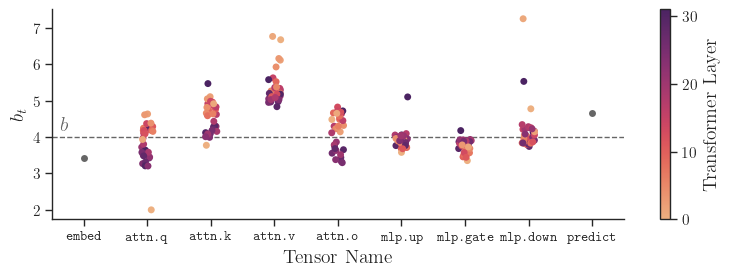

In [ ]:
types = dict(embed_tokens="embed", q_proj="attn.q", k_proj="attn.k", v_proj="attn.v", o_proj="attn.o",
             up_proj="mlp.up", gate_proj="mlp.gate", down_proj="mlp.down", lm_head="predict")

_, ax = plt.subplots()
sns.stripplot(data=df, y="bits", x="type", order=types, hue="layer", palette=plot_utils.SEQ_PALETTE, ax=ax)
sns.stripplot(data=df[df.layer.isna()], y="bits", x="type", order=types, ax=ax, color="#666")
ax.axhline(average_bits, color="#666", lw=1, ls="--")
ax.annotate("$b$", [0, average_bits], (-17, 5), textcoords="offset points", color="#666")

ax.set_xticks(range(len(types)))
ax.set_xticklabels([f"\\texttt{{{types[label.get_text()]}}}" for label in ax.get_xticklabels()], fontsize=10)
ax.set_xlabel("Tensor Name")
ax.set_ylabel(r"$b_t$")

ax.legend_.remove()
sm = matplotlib.cm.ScalarMappable(norm=matplotlib.colors.Normalize(0, df.layer.max()), cmap=plot_utils.SEQ_PALETTE)
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label("Transformer Layer")

plot_utils.tidy(ax.figure)
plot_utils.save("fisher_bit_allocation")

### `empirical_fisher`

In [ ]:
model = "meta-llama/Llama-3.1-8B"
fisher = E.fisher.fetch_fisher_sum(model, "20250423-fisher")
empirical_fisher = E.fisher.fetch_fisher_sum(model, "20250505-empirical-fisher")
nelement = {k: math.prod(v.shape) for k, v in E.weight_stats.fetch_weight_stats(model, "20250423-weight-stats").items()}

remote: Updating references: 100% (1/1)           


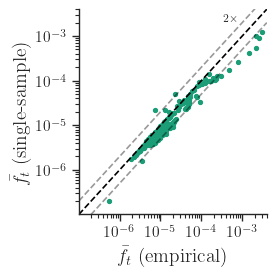

In [57]:
_, ax = plt.subplots(figsize=(3, 3))
ax.scatter([empirical_fisher[k] / nelement[k] for k in empirical_fisher],
           [fisher[k] / nelement[k] for k in empirical_fisher])
ax.set_xscale("log")
ax.set_yscale("log")
xs = tensor([1e-7, 4e-3])
ax.plot(xs, xs, "k--")
ax.plot(xs, 2 * xs, "k--", alpha=.4)
ax.plot(xs, xs / 2, "k--", alpha=.4)
ax.annotate(r"$2\times$", [10**-3, 2*10**-3], ha="right", va="bottom", fontsize=8, xytext=(-3, 0), textcoords="offset points")
ax.set_xlim(xs)
ax.set_ylim(xs)
ax.set_xlabel(r"$\bar{f}_t$ (empirical)")
ax.set_ylabel(r"$\bar{f}_t$ (single-sample)")

plot_utils.tidy(ax.figure)
plot_utils.save("empirical_fisher")